In [2]:
import sympy as sp


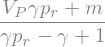

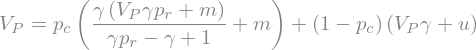

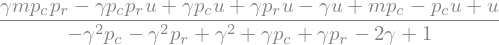

In [11]:
sp.init_printing()

V_P, V_D = sp.symbols('V_P, V_D')
p_c, p_r = sp.symbols('p_c, p_r')
u, m = sp.symbols('u, m')
gamma = sp.symbols('\gamma')


V_P_eqn = sp.Eq(V_P, (1 - p_c)*(u + gamma*V_P) + p_c*(m + gamma*V_D))
display(V_P_eqn)

V_D_eqn = sp.Eq(V_D, m + gamma*((1 - p_r)*(V_D) + p_r*V_P))
display(V_D_eqn)

V_D_solve = sp.solve(V_D_eqn, V_D)[0]
display(V_D_solve)

V_P_with_V_D_subs = V_P_eqn.subs(V_D, V_D_solve)
display(V_P_with_V_D_subs)

V_P_solve = sp.solve(V_P_with_V_D_subs, V_P)[0]
display(V_P_solve)





In [4]:
print(sp.latex(V_P_eqn))
print(sp.latex(V_D_eqn))
print(sp.latex(V_D_solve))
print(sp.latex(V_P_with_V_D_subs))
print(sp.latex(V_P_solve))

V_{P} = p_{c} \left(V_{D} \gamma + m\right) + \left(1 - p_{c}\right) \left(V_{P} \gamma + u\right)
V_{D} = \gamma \left(V_{D} \left(1 - p_{r}\right) + V_{P} p_{r}\right) + m
\frac{V_{P} \gamma p_{r} + m}{\gamma p_{r} - \gamma + 1}
V_{P} = p_{c} \left(\frac{\gamma \left(V_{P} \gamma p_{r} + m\right)}{\gamma p_{r} - \gamma + 1} + m\right) + \left(1 - p_{c}\right) \left(V_{P} \gamma + u\right)
\frac{\gamma m p_{c} p_{r} - \gamma p_{c} p_{r} u + \gamma p_{c} u + \gamma p_{r} u - \gamma u + m p_{c} - p_{c} u + u}{- \gamma^{2} p_{c} - \gamma^{2} p_{r} + \gamma^{2} + \gamma p_{c} + \gamma p_{r} - 2 \gamma + 1}


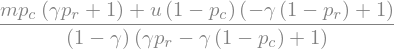

True
\frac{m p_{c} \left(\gamma p_{r} + 1\right) + u \left(1 - p_{c}\right) \left(- \gamma \left(1 - p_{r}\right) + 1\right)}{\left(1 - \gamma\right) \left(\gamma p_{r} - \gamma \left(1 - p_{c}\right) + 1\right)}


In [13]:
num = m*p_c*(gamma*p_r + 1) + u*(1- p_c)*(1 - gamma*(1 - p_r))

# den = (1 - gamma) * (gamma*(p_c + p_r - 1) + 1)
den = (1 - gamma) * ((1 - gamma*(1 - p_c)) + gamma*p_r)

expr = num / den

display(expr)

print(sp.simplify(V_P_solve - expr).equals(0))

print(sp.latex(expr))


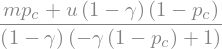

In [6]:
simplified_subs_pr_0 = expr.subs(p_r, 0)
display(simplified_subs_pr_0)

In [9]:
from sympy.parsing.latex import parse_latex

latex_expr = parse_latex(r"\frac{m p_{c} \left(1 + \gamma p_{r}\right) + u \left(1 - p_{c}\right) \left(1 - \gamma \left(1 - p_{r}\right)\right)}{\left(1 - \gamma\right) \left(1 - \gamma \left(1 - p_{c} + \gamma p_{r} \right) \right)}")

In [20]:
latex_expr_2 = latex_expr = parse_latex(
    r"\frac{m \cdot p_c (1 + \gamma \cdot p_r) + u \cdot (1 - p_c)(1 - \gamma (1 - p_r))}"
    r"{(1 - \gamma)(1 - \gamma (1 - p_c + \gamma \cdot p_r))}"
)

In [ ]:
vals = {m:1, p_c:0.3, p_r:0.4, gamma:0.5, u:2}

print(sp.N(V_P_solve.subs(vals)))
print(sp.N(latex_expr_2.subs(vals)))

3.15294117647059
(2.0*(1.0 - p_{c})*(1.0 - gamma(1 - p_{r})) + p_{c}(gamma*p_{r} + 1))/((1.0 - gamma)*(1.0 - gamma(gamma*p_{r} + (1 - p_{c}))))


: 